In [19]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
sns.set(palette='Dark2' ,style='darkgrid' )
import warnings
warnings.filterwarnings('ignore')

In [20]:
df=pd.read_csv('Churn_Modelling.csv')

In [21]:
df=df.drop(['Surname','CustomerId','RowNumber'] , axis=1)

In [22]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
df=pd.get_dummies(df , columns=['Geography','Gender'] , drop_first=True)

In [24]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [25]:
x=df.drop('Exited' , axis=1)
y=df.Exited
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [26]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [27]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [28]:
model = Sequential()
model.add(Dense(6,activation='sigmoid' , input_dim=11))
model.add(Dense(6,activation='sigmoid' ))
model.add(Dense(6,activation='sigmoid' ))
model.add(Dense(6,activation='sigmoid' ))
model.add(Dense(3,activation='sigmoid' ))
model.add(Dense(1,activation='sigmoid'))

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223 (892.00 B)

 Trainable params: 223 (892.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(loss='binary_crossentropy' , optimizer='Adam',metrics=['accuracy'])

In [31]:
history=model.fit(x_train_scaled,y_train,epochs=60 ,validation_split=0.2 )

Epoch 1/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4299 - loss: 0.7055 - val_accuracy: 0.8062 - val_loss: 0.5666
Epoch 2/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7984 - loss: 0.5526 - val_accuracy: 0.8062 - val_loss: 0.5116
Epoch 3/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8072 - loss: 0.5062 - val_accuracy: 0.8062 - val_loss: 0.4976
Epoch 4/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7853 - loss: 0.5208 - val_accuracy: 0.8062 - val_loss: 0.4933
Epoch 5/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8056 - loss: 0.4938 - val_accuracy: 0.8062 - val_loss: 0.4921
Epoch 6/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7985 - loss: 0.5024 - val_accuracy: 0.8062 - val_loss: 0.4915
Epoch 7/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7980 - loss: 0.5028 - val_accuracy: 0.8062 - val_loss: 0.4910
Epoch 8/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7993 - loss: 0.5005 - val_accuracy: 0.

In [32]:
y_log = model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [33]:
y_pred = np.where(y_log>0.5,1,0)

In [34]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.797

<Axes: >

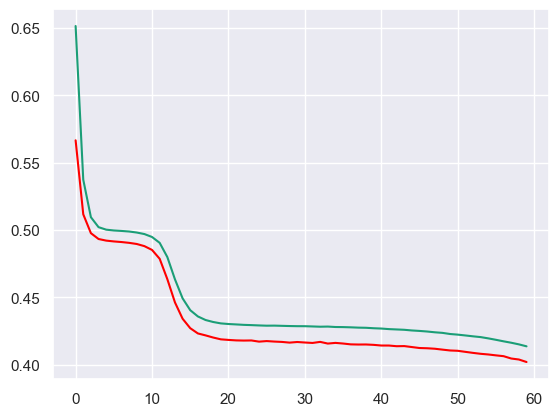

In [35]:
sns.lineplot(history.history['loss'])
sns.lineplot(history.history['val_loss'] , c='r')

<Axes: >

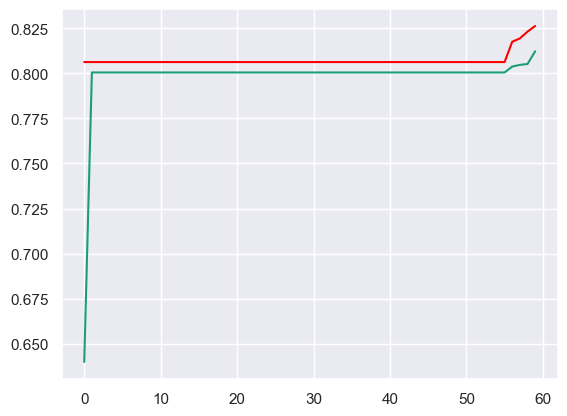

In [36]:
sns.lineplot(history.history['accuracy'])
sns.lineplot(history.history['val_accuracy'] , c='r')